In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np

import rydstate

logging.basicConfig(level=logging.ERROR)

In [2]:
class Strontium88Kostelecky(rydstate.species.Strontium88):
    name = "Sr88_kostelecky"
    potential_type_default = "potential_kostelecky_1985"

In [3]:
state1 = rydstate.RydbergStateSQDTAlkalineLS("Sr88_kostelecky", n=19, l=0, j_tot=1, s_tot=1, m=1)
state2 = rydstate.RydbergStateSQDTAlkalineLS("Sr88_kostelecky", n=5, l=1, j_tot=1, s_tot=1, m=1)

radial = state1.radial.calc_matrix_element(state2.radial, k_radial=1)
print(radial)

-0.0802754253762901 bohr


In [4]:
state = rydstate.RydbergStateSQDTAlkalineLS("Sr88_kostelecky", n=19, l=0, j_tot=1, s_tot=1, m=1)

temperature = 300  # Kelvin
lifetime_0 = state.get_lifetime()
lifetime = state.get_lifetime(temperature, temperature_unit="K")

print(f"Lifetime at T=0: {lifetime_0.to('mus'):.4f}")
print(f"Lifetime at T={temperature}K: {lifetime.to('mus'):.4f}")
print(f"Lifetime*2*pi at T={temperature}K: {lifetime.to('mus') * 2 * np.pi:.4f}")


Lifetime at T=0: 1.9996 microsecond
Lifetime at T=300K: 1.7584 microsecond
Lifetime*2*pi at T=300K: 11.0481 microsecond


Number of possible spontaneous decay transitions: 84
Number of considered BBR transitions: 276


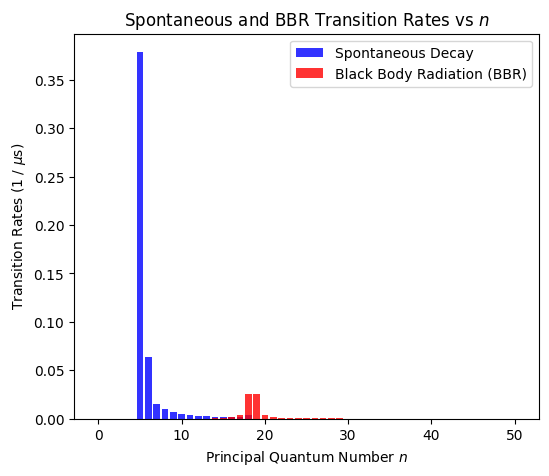

In [5]:
# Calculate the transition rates
state_sp, transition_rates_sp = state.get_spontaneous_transition_rates(unit="1/mus")
print(f"Number of possible spontaneous decay transitions: {len(transition_rates_sp)}")

state_bbr, transition_rates_bbr = state.get_black_body_transition_rates(temperature, "kelvin", unit="1/mus")
print(f"Number of considered BBR transitions: {len(transition_rates_bbr)}")

# Plot the transition rates
fig, ax = plt.subplots(figsize=(6, 5))

n_list = np.arange(0, np.max([s.n for s in state_bbr]) + 1)
rates_summed = {}
for key, state, rates in [
    ("BBR", state_bbr, transition_rates_bbr),
    ("SP", state_sp, transition_rates_sp),
]:
    rates_summed[key] = np.zeros(len(n_list))
    for i, s in enumerate(state):
        rates_summed[key][s.n] += rates[i]

ax.bar(n_list, rates_summed["SP"], label="Spontaneous Decay", color="blue", alpha=0.8)
ax.bar(n_list, rates_summed["BBR"], label="Black Body Radiation (BBR)", color="red", alpha=0.8)
ax.legend()

ax.set_xlabel("Principal Quantum Number $n$")
ax.set_ylabel(r"Transition Rates (1 / $\mu$s)")
ax.set_title("Spontaneous and BBR Transition Rates vs $n$")

plt.show()